# SignalScope AI — Baseline Classification Model

This notebook builds the first machine-learning baseline for SignalScope AI.

The goal is to classify particle-collision events as **signal** or **background** and establish a baseline before exploring more advanced models and explainability methods.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("SignalScope AI environment ready!")

SignalScope AI environment ready!


## 1. Load the Dataset

We begin with a 10,000-event subset of the HIGGS particle-collision dataset used during the exploratory data analysis stage of the project.


In [15]:
df = pd.read_csv(
    "sample_data/higgs_train_10k.csv.zip",
    compression="zip",
    header=None
)

print("Dataset shape:", df.shape)

Dataset shape: (10000, 29)


In [16]:
#Define target and features

y = df.iloc[:, 0]
X = df.iloc[:,1:]

print("Features matrix shape:", X.shape)
print("Taarget shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features matrix shape: (10000, 28)
Taarget shape: (10000,)

Target distribution:
0
1    5295
0    4705
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

Training set: (8000, 28)
Test set: (2000, 28)

Training target distribution:
0
1    4236
0    3764
Name: count, dtype: int64

Test target distribution:
0
1    1059
0     941
Name: count, dtype: int64


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Create and train the baseline model
model = LogisticRegression(
    max_iter= 1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Baseline model trained successfully!")



Baseline model trained successfully!


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
#Make predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

#Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC Score:", roc_auc)

Accuracy: 0.628
Precision: 0.6296296296296297
Recall: 0.7223796033994334
F1 Score: 0.6728232189973615
ROC AUC Score: 0.6731763267935684


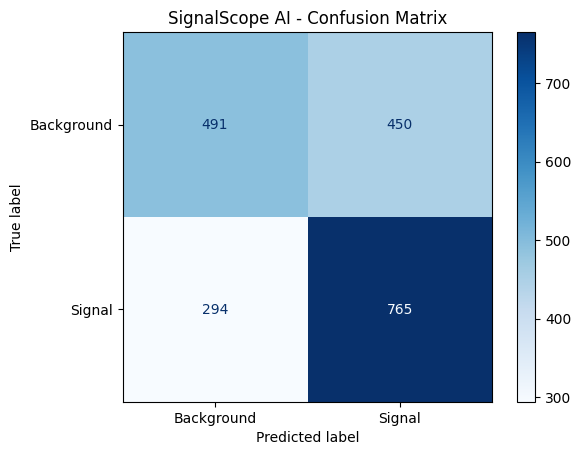

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Background", "Signal"],
    cmap="Blues"
)
plt.title("SignalScope AI - Confusion Matrix")
plt.show()

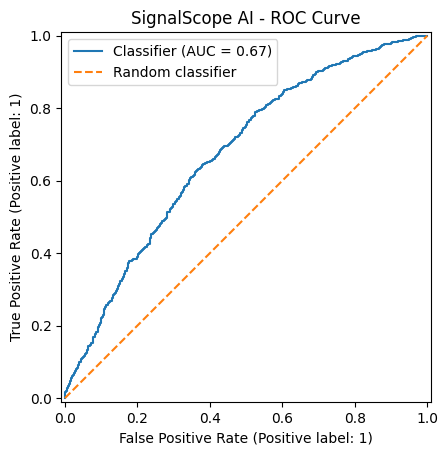

In [26]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)
plt.plot([0,1],[0,1], "--", label ="Random classifier")
plt.title("SignalScope AI - ROC Curve")
plt.legend()
plt.show()

### Baseline Model Interpretation

The Logistic Regression baseline achieved an ROC-AUC score of approximately **0.67**.

The model correctly identified **765 out of 1,059 signal events**, corresponding to a recall of approximately **72.2%**. However, it also classified **450 background events as signal**, indicating that a linear decision boundary is not sufficient to fully capture the complex relationships in the data.

These results provide a useful baseline for comparison with more powerful non-linear models.